# HEART DISEASE PREDICTION USING MACHINE LEARNING
## Introduction

Cardiovascular disease remains one of the leading causes of mortality worldwide. Early identification of individuals at high risk is critical for timely intervention, improved patient management, and reduction of adverse outcomes. With the increasing availability of structured clinical and demographic health data, machine learning techniques provide a powerful approach for predictive diagnosis and decision support in cardiovascular care.

This project applies supervised machine learning models to predict the presence of heart disease using structured patient data derived from the Cleveland Heart Disease database.
## Data Source:
The dataset is originally derived from the Cleveland Heart Disease database available through the UCI Machine Learning Repository. This dataset contains clinical information related to heart disease
For this study, I utilized a preprocessed version of the dataset obtained from Kaggle. While the original database consists of 76 attributes, this analysis is limited to 14 selected features.
https://archive.ics.uci.edu/dataset/45/heart+disease
## Target Variable:
The dependent variable represents the presence or absence of heart disease.
0 → No heart disease
1 → Presence of heart disease
## Purpose of the Project
The primary objectives of this project are:
1.To explore and understand the structure of the heart disease dataset.
2.To perform exploratory data analysis (EDA) to identify patterns, trends, and relationships among variables.
3.To preprocess and prepare the dataset for machine learning modeling.
4.To implement and compare multiple supervised classification models, including Logistic Regression, KNN, SVM, and Random Forest.
5.To evaluate model performance using appropriate metrics such as accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.
6.To identify the best-performing modelbased on discrimination ability.
7.To determine the most predictive clinical features using permutation importance.
8.To interpret findings from both a statistical and clinical perspective.
The ultimate goal is to determine which model most effectively predicts heart disease and to identify the key risk factors that contribute most strongly to disease classification.

# 1. Data Loading and Initial Inspection

In [2]:
# importing necessary libraries for EDA and visualizations
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("C:/Users/drhud/Downloads/heart.csv")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
data.shape

(303, 14)

## DATA DESCRIPTION 
### 1.Age: The patient's age in years.
### 2.Sex: The patient's sex (1 = male, 0 = female).
### 3.Chest Pain Type (cp):
 0: Typical angina
 1: Atypical angina
 2: Non-anginal pain
 3: Asymptomatic
### 4.Resting Blood Pressure (trestbps): Resting blood pressure (in mm Hg).
### 5.Cholesterol (chol): Serum cholesterol level (in mg/dL).
### 6.Fasting Blood Sugar (fbs):
 1: Fasting blood sugar > 120 mg/dL
 0: Fasting blood sugar ≤ 120 mg/dL
### 7.Resting Electrocardiographic Results (restecg):
 0: Normal
 1: ST-T wave abnormality
 2: Left ventricular hypertrophy
### 8.Maximum Heart Rate Achieved (thalach): Maximum heart rate achieved during exercise.
### 9.Exercise-Induced Angina (exang):
 1: Yes
 0: No
### 10.ST Depression Induced by Exercise Relative to Rest (oldpeak): ST depression induced by exercise relative to rest.
### 11.Slope of the Peak Exercise ST Segment (slope):
 0: Upsloping
 1: Flat
 2: Downsloping
### 12.Number of Major Vessels Colored by Fluoroscopy (ca): Number of major vessels (0-3) colored by fluoroscopy.
### 13.Thallium heart scan (thal):
 3: Normal
 6: Fixed defect
 7: Reversible defect
### 14.target - have disease or not (1=yes, 0=no) (= the predicted attribute)

# 2. DATA CLEANING
I renamed the column names to more descriptive and clinically meaningful labels to improve clarity. I removed invalid values from the major vessels number and thallium heart scan variables to ensure data quality, resulting in a cleaned dataset of 296 observations. I then created separate copies of the dataset for exploratory data analysis and machine learning modeling. For the EDA dataset, I mapped the categorical variables to readable category labels to make the visualizations and analysis easier to interpret.

In [6]:
# renaming columns for clarity 
data = data.rename( columns = {'cp':'chest_pain',
                               'trestbps':'resting_blood_pressure',
                               'chol':'cholesterol',
                               'fbs':'fasting_blood_sugar',
                               'restecg':'resting_ecg',       
                               'thalach':'max_heartrate_achieved',
                               'exang':'exercise_induced_angina',         
                               'oldpeak':'st_depression',     
                               'slope':'st_segment_slope',         
                               'ca':'major_vessels_number',
                               'thal':'thallium_heart_scan'}, errors = "raise")       

In [7]:
data = data[data['major_vessels_number'] < 4]      # keep only valid ca values (0–3)
data = data[data['thallium_heart_scan'] > 0]   # keep only valid thal values (>0)


In [8]:
data.shape

(296, 14)

In [9]:
data_eda = data.copy()
data_ml = data.copy()

In [10]:
#Sex
data_eda['sex'] = data_eda['sex'].map({0 :'female', 1:'male'})
# Chest pain type
data_eda['chest_pain'] = data_eda['chest_pain'].map({0: 'Typical angina',
                                                     1: 'Atypical angina',
                                                     2: 'Non-anginal pain',
                                                     3: 'Asymptomatic'})

# Fasting blood sugar
data_eda['fasting_blood_sugar']= data_eda['fasting_blood_sugar'].map({1:'Fasting blood sugar > 120 mg/dL',
                                                                            0:'Fasting blood sugar ≤ 120 mg/dL'})
# Resting ECG
data_eda['resting_ecg']= data_eda['resting_ecg'].map({0:'Normal',
                                                      1:'ST-T wave abnormality',
                                                      2:'Left ventricular hypertrophy'})
# Exercise induced angina
data_eda['exercise_induced_angina'] = data_eda['exercise_induced_angina'].map({1:'Yes',
                                                                               0:'No'})

# ST slope
data_eda['st_segment_slope'] = data_eda['st_segment_slope'].map({0: 'upsloping',
                                                                  1: 'flat',
                                                                  2: 'downsloping'})

#thallium heart scan
data_eda['thallium_heart_scan'] = data_eda['thallium_heart_scan'].map({1: 'normal',
                                                       2: 'fixed defect',
                                                       3: 'reversible defect'})

In [11]:
data_eda.head()

,age,sex,chest_pain,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heartrate_achieved,exercise_induced_angina,st_depression,st_segment_slope,major_vessels_number,thallium_heart_scan,target
0,63,male,Asymptomatic,145,233,Fasting blood sugar > 120 mg/dL,Normal,150,No,2.3,upsloping,0,normal,1
1,37,male,Non-anginal pain,130,250,Fasting blood sugar ≤ 120 mg/dL,ST-T wave abnormality,187,No,3.5,upsloping,0,fixed defect,1
2,41,female,Atypical angina,130,204,Fasting blood sugar ≤ 120 mg/dL,Normal,172,No,1.4,downsloping,0,fixed defect,1
3,56,male,Atypical angina,120,236,Fasting blood sugar ≤ 120 mg/dL,ST-T wave abnormality,178,No,0.8,downsloping,0,fixed defect,1
4,57,female,Typical angina,120,354,Fasting blood sugar ≤ 120 mg/dL,ST-T wave abnormality,163,Yes,0.6,downsloping,0,fixed defect,1


In [12]:
data_eda.dtypes

age                          int64
sex                         object
chest_pain                  object
resting_blood_pressure       int64
cholesterol                  int64
fasting_blood_sugar         object
resting_ecg                 object
max_heartrate_achieved       int64
exercise_induced_angina     object
st_depression              float64
st_segment_slope            object
major_vessels_number         int64
thallium_heart_scan         object
target                       int64
dtype: object

In [13]:
data_eda.isna().sum()

age                        0
sex                        0
chest_pain                 0
resting_blood_pressure     0
cholesterol                0
fasting_blood_sugar        0
resting_ecg                0
max_heartrate_achieved     0
exercise_induced_angina    0
st_depression              0
st_segment_slope           0
major_vessels_number       0
thallium_heart_scan        0
target                     0
dtype: int64

# 3. EXPLORATORY DATA ANALYSIS 
## 3.1 Target Distribution

In [14]:
#count how many patients have heart disease (1) and how many do not (0)
data_eda['target'].value_counts()


target
1    160
0    136
Name: count, dtype: int64

In [15]:
# percentage version
data_eda['target'].value_counts(normalize=True) * 100


target
1    54.054054
0    45.945946
Name: proportion, dtype: float64

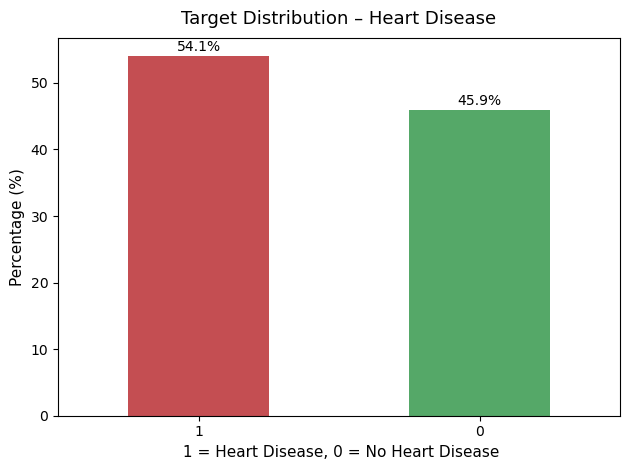

In [16]:
import matplotlib.pyplot as plt

# Plot
ax = (data_eda['target'].value_counts(normalize=True) * 100).plot(
    kind='bar',
    color= ['#C44E52', '#55A868']
)

# Titles and labels
plt.title("Target Distribution – Heart Disease", fontsize=13, pad=10)
plt.xlabel(" 1 = Heart Disease, 0 = No Heart Disease", fontsize=11)
plt.xticks(rotation=0)
plt.ylabel("Percentage (%)", fontsize=11)

# Add percentage labels on top of bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


### Interpretation of Target Distribution

The dataset contains 160 patients (54.1%) with heart disease and 136 patients (45.9%) without heart disease.

This indicates that the dataset is relatively balanced, with a slight majority of disease cases.

In [17]:
# separate categorical features and numerical features 
target= "target"

cat_cols = [ "sex",
    "chest_pain",
    "fasting_blood_sugar",
    "resting_ecg",
    "exercise_induced_angina",
    "st_segment_slope",
    "thallium_heart_scan"
] 

num_cols = [
    "age",
    "resting_blood_pressure",
    "cholesterol",
    "max_heartrate_achieved",
    "st_depression",
    "major_vessels_number"
]

print("Categorical features", cat_cols)
print("Numerical features", num_cols)
                  

Categorical features ['sex', 'chest_pain', 'fasting_blood_sugar', 'resting_ecg', 'exercise_induced_angina', 'st_segment_slope', 'thallium_heart_scan']
Numerical features ['age', 'resting_blood_pressure', 'cholesterol', 'max_heartrate_achieved', 'st_depression', 'major_vessels_number']


## 3.2 Categorical Features vs Heart Disease

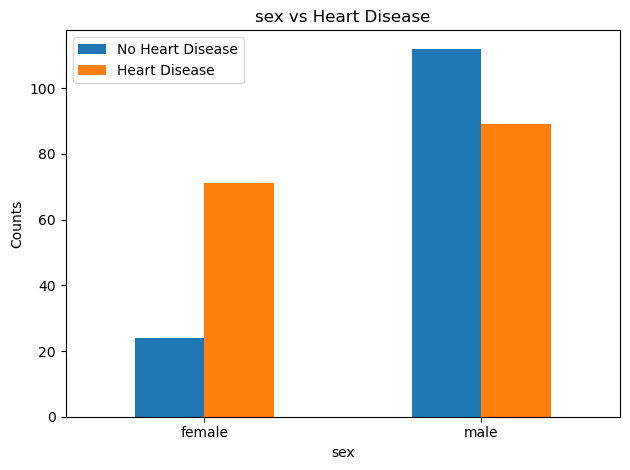

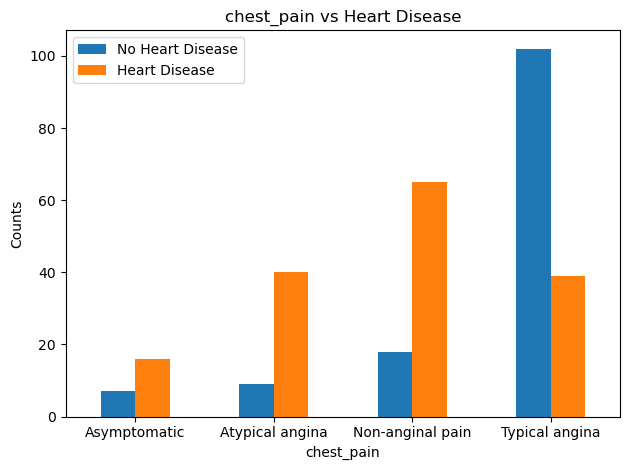

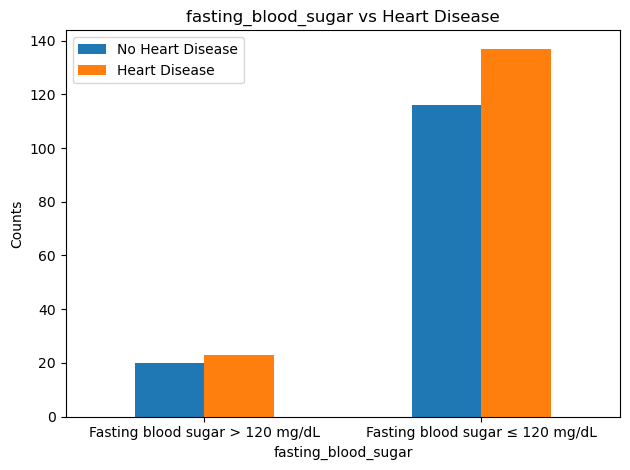

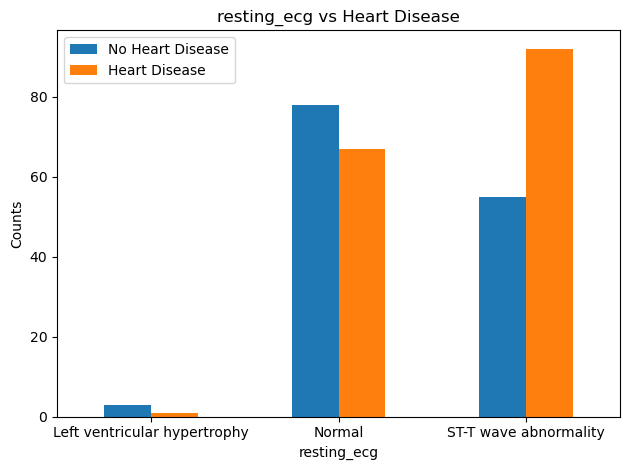

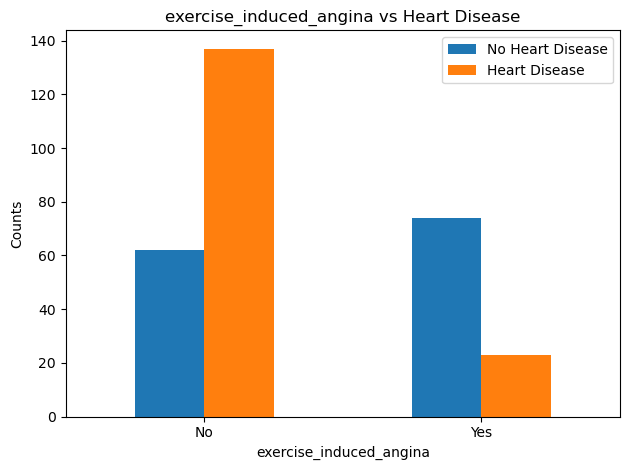

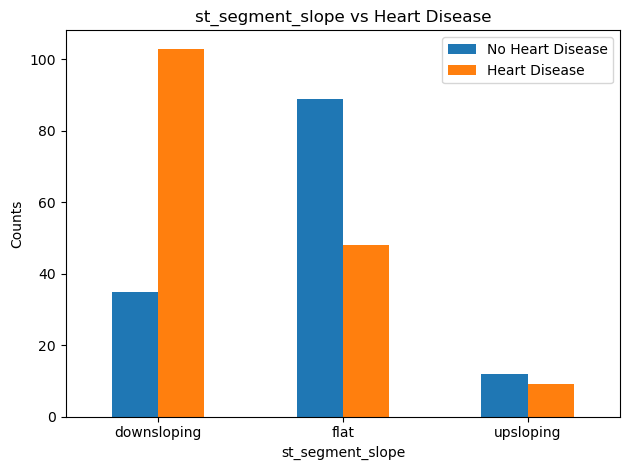

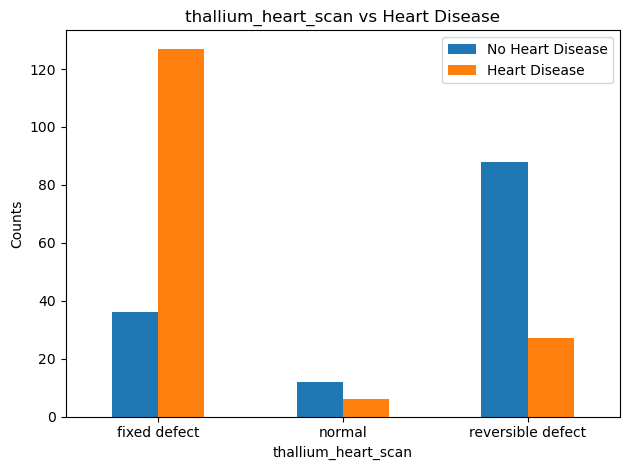

In [18]:
#PLOT 1 : Categorical features vs target

target = "target"

for col in cat_cols:
    counts = data_eda.groupby([col, target]).size().unstack(fill_value=0)

    counts.plot(kind="bar")

    plt.title(f"{col} vs Heart Disease")
    plt.xlabel(col)
    plt.xticks(rotation=0) 
    plt.ylabel("Counts")
    plt.legend(["No Heart Disease", "Heart Disease"])

    plt.tight_layout()
    plt.show()


## Interpretation
### Sex vs Heart Disease
The distribution indicates that males have a higher number of heart disease cases compared to females. However, since males are more represented in the dataset overall, this difference may partially reflect sample composition rather than solely increased risk.
### Chest Pain vs Heart Disease
Chest pain type shows clear differentiation between groups. Asymptomatic, atypical angina, and non-anginal pain categories display higher counts in the disease group, while typical angina is more common among non-disease cases. This suggests chest pain presentation is strongly associated with heart disease status.
### Fasting Blood Sugar vs Heart Disease
The distribution of fasting blood sugar appears similar across disease and non-disease groups, indicating weak differentiation. This suggests fasting blood sugar alone may have limited predictive value in this dataset.
### Resting ECG vs Heart Disease
ST-T wave abnormalities appear more frequently among disease cases, while normal ECG results are present in both groups. The separation is moderate, indicating some association but not as strong as other diagnostic features.
### Exercise-Induced Angina vs Heart Disease
Exercise-induced angina shows noticeable differences between groups, indicating an association with heart disease status. However, the pattern suggests a complex relationship rather than a straightforward increase in disease with angina presence.
### ST Segment Slope vs Heart Disease
Downsloping ST segment patterns are more common in disease cases, while flat slopes are more frequent in non-disease cases. This suggests ST segment slope is meaningfully associated with heart disease classification.
### Thallium Heart Scan vs Heart Disease
Thallium scan results show clear separation between groups, with fixed defects strongly concentrated among disease cases. This indicates a strong association between imaging abnormalities and heart disease.
### Overall Interpretation
Diagnostic and stress-related cardiac features — including thallium heart scan, ST segment slope, exercise-induced angina, ST depression, maximum heart rate achieved, and chest pain type — show clearer differentiation between disease and non-disease groups compared to metabolic variables such as fasting blood sugar. This suggests that direct cardiac pathology and functional indicators play a stronger role in distinguishing heart disease status in this dataset.

## 3.3 Numerical Feature Exploration

In [20]:
# Statistical sumarry of numerical features 
data_eda[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,296.0,54.523649,9.059471,29.0,48.0,56.0,61.00,77.0
resting_blood_pressure,296.0,131.604730,17.726620,94.0,120.0,130.0,140.00,200.0
cholesterol,296.0,247.155405,51.977011,126.0,211.0,242.5,275.25,564.0
max_heartrate_achieved,296.0,149.560811,22.970792,71.0,133.0,152.5,166.00,202.0
st_depression,296.0,1.059122,1.166474,0.0,0.0,0.8,1.65,6.2
major_vessels_number,296.0,0.679054,0.939726,0.0,0.0,0.0,1.00,3.0


<Figure size 600x400 with 0 Axes>

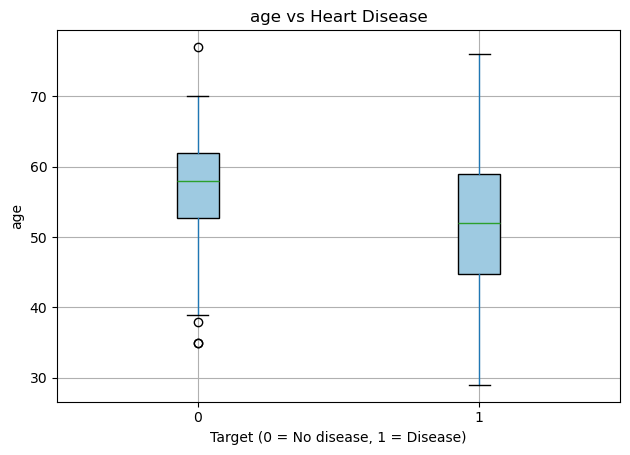

<Figure size 600x400 with 0 Axes>

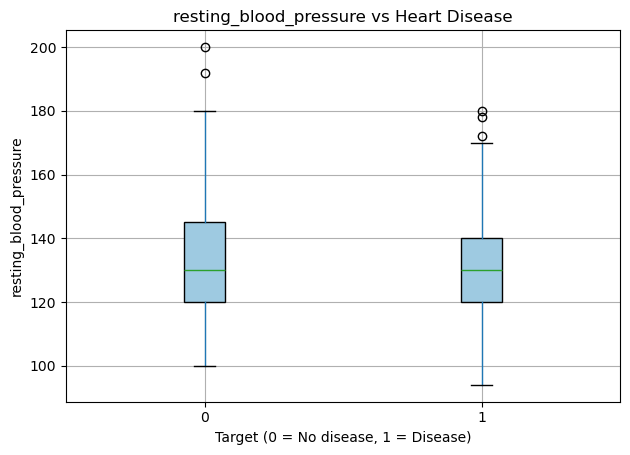

<Figure size 600x400 with 0 Axes>

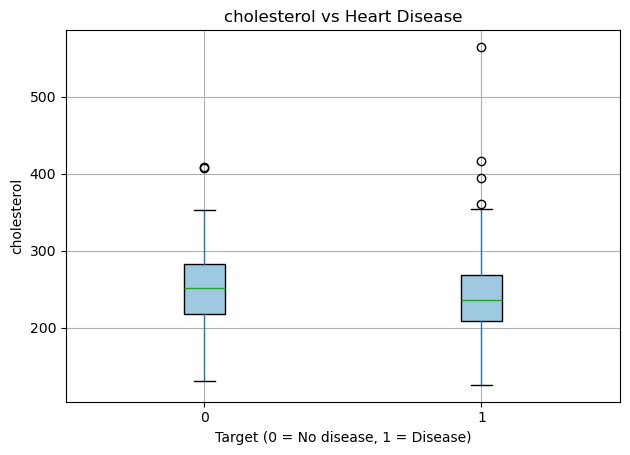

<Figure size 600x400 with 0 Axes>

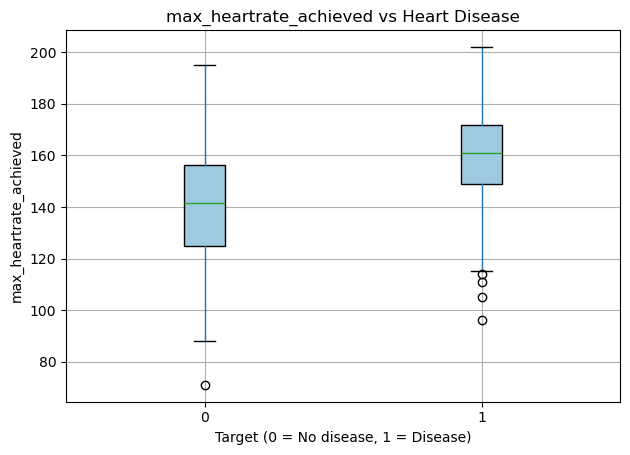

<Figure size 600x400 with 0 Axes>

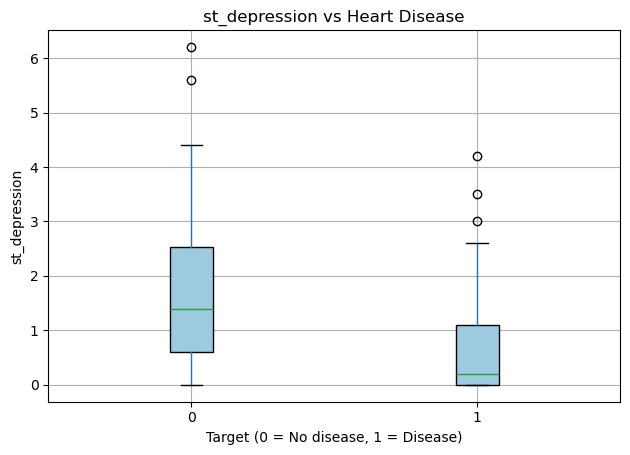

<Figure size 600x400 with 0 Axes>

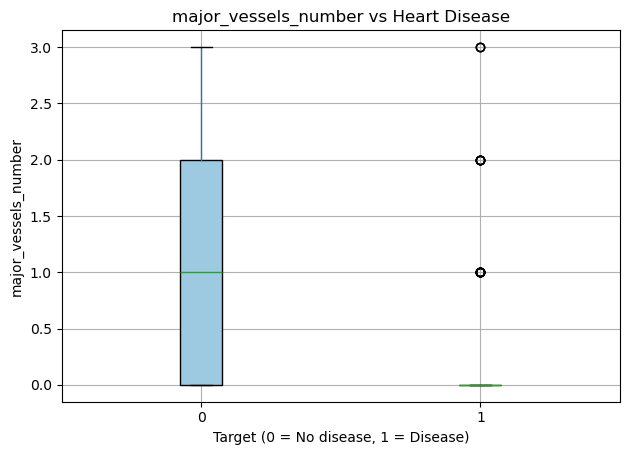

In [21]:
# PLOT 2 : Numerical features vs target 
for col in num_cols:
    plt.figure(figsize=(6,4))

    data_eda.boxplot(column=col, by="target", patch_artist=True, 
        boxprops=dict(facecolor="#9ecae1") 
    )

    plt.title(f"{col} vs Heart Disease")
    plt.xlabel("Target (0 = No disease, 1 = Disease)")
    plt.ylabel(col)

    plt.suptitle("")  
    plt.tight_layout()
    plt.show()


## Interpretation
### Age vs Heart Disease
The age distribution shows overlap between groups, though disease cases appear slightly concentrated in older individuals. However, the separation is moderate, suggesting age alone does not strongly distinguish disease status.
### Resting Blood Pressure vs Heart Disease
Resting blood pressure shows substantial overlap between disease and non-disease groups, with similar medians and spread. This indicates limited standalone discriminatory power.
### Cholesterol vs Heart Disease
Cholesterol levels display wide variability in both groups, with considerable overlap. Although some high outliers are present, cholesterol does not show clear separation between disease and non-disease cases.
### Maximum Heart Rate Achieved vs Heart Disease
There is visible separation between groups, with disease cases generally showing different heart rate distributions compared to non-disease cases. This suggests exercise capacity is meaningfully associated with heart disease classification.
### ST Depression vs Heart Disease
ST depression shows noticeable differences between groups, with one group exhibiting higher central values and greater spread. This indicates that ischemic stress response is relevant in distinguishing heart disease.
### Major Vessels Number vs Heart Disease
The distribution shows clearer separation, with higher vessel counts appearing more frequently in disease cases. This suggests structural coronary involvement is strongly associated with heart disease status.
### Overall Interpretation
Among the numerical features, maximum heart rate achieved, ST depression, and major vessels number show clearer differentiation between groups, while age, resting blood pressure, and cholesterol exhibit greater overlap. This indicates that functional and structural cardiac markers provide stronger discriminatory value than general cardiovascular risk factors in this dataset.

## 5.4 Correlation Analysis

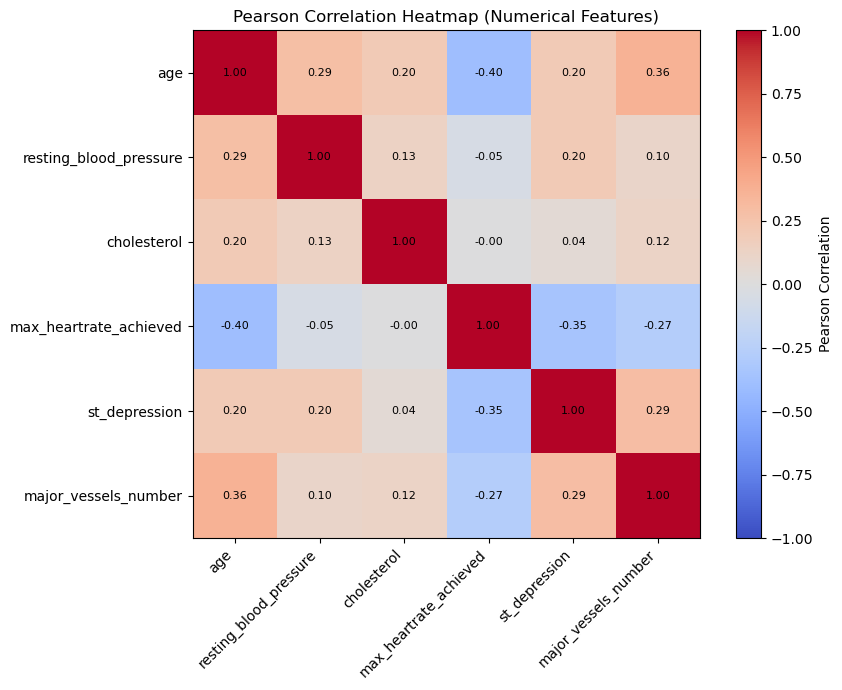

In [23]:
# CORRELATION : PEARSON CORRELATION for numerical features 
corr = data_eda[num_cols].corr(method="pearson")
plt.figure(figsize=(9, 7))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Pearson Correlation")

plt.xticks(
    ticks=np.arange(len(num_cols)),
    labels=num_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(num_cols)),
    labels=num_cols
)

plt.title("Pearson Correlation Heatmap (Numerical Features)")

# Optional: show values inside cells
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()


## Interpretation 
The correlation heatmap reveals mostly weak to moderate linear relationships among numerical features, with no evidence of strong multicollinearity. Age shows a moderate negative association with maximum heart rate, and ST depression relates modestly to major vessel involvement. Overall, the predictors provide relatively independent information, supporting stable machine learning modeling.

## 3.5 Association Analysis of Categorical Features Using Cramér’s V
Cramér’s V was used to measure the strength of association between categorical variables and the target variable

In [24]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def cramers_v(col, target, df):
    table = pd.crosstab(df[col], df[target])
    chi2, _, _, _ = chi2_contingency(table)
    n = table.sum().sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))

cramer_values = {}

for col in cat_cols:
    cramer_values[col] = cramers_v(col, "target", data_eda)

cramer_df = pd.DataFrame.from_dict(cramer_values, orient="index", columns=["Cramers_V"])
cramer_df.sort_values("Cramers_V", ascending=False)


,Cramers_V
thallium_heart_scan,0.531968
chest_pain,0.508223
exercise_induced_angina,0.417864
st_segment_slope,0.387964
sex,0.278061
resting_ecg,0.176895
fasting_blood_sugar,0.000000


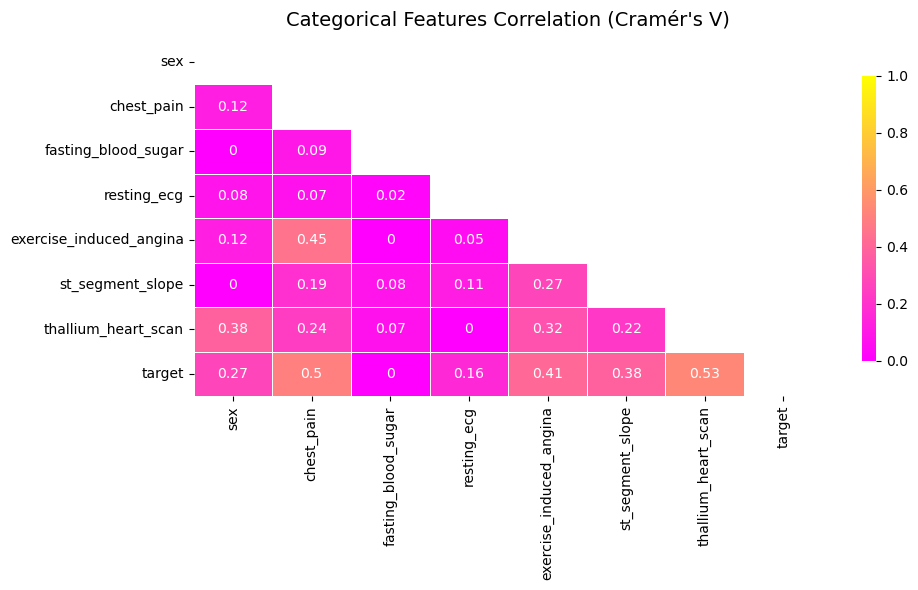

In [25]:
from scipy import stats

# Cramér’s V 
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# choose categorical columns
cat_feats = cat_cols + ["target"]

data_ = data_eda[cat_feats]

# build matrix
rows = []
for x in data_.columns:
    col_vals = []
    for y in data_.columns:
        col_vals.append(round(cramers_v(data_[x], data_[y]), 2))
    rows.append(col_vals)

df_cramer = pd.DataFrame(rows, columns=data_.columns, index=data_.columns)

# triangular mask
mask = np.triu(np.ones_like(df_cramer, dtype=bool))

# plot
plt.figure(figsize=(10, 6))
sns.heatmap(df_cramer, mask=mask, cmap="spring", vmin=0, vmax=1,
            annot=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Categorical Features Correlation (Cramér's V)", fontsize=14, pad=10)
plt.tight_layout()
plt.show()


## Interpretation
 Thallium heart scan shows the strongest relationship with the target variable, followed by chest pain, exercise-induced angina, and ST segment slope, suggesting these diagnostic and stress-related cardiac features are important indicators of heart disease. Sex shows a moderate association, while resting ECG demonstrates a weaker relationship. Fasting blood sugar shows almost no association with heart disease, indicating limited predictive relevance in this dataset.
Overall, the analysis suggests that clinical diagnostic indicators and cardiac stress responses have stronger relationships with heart disease than metabolic indicators

# 4. Machine Learning Modeling
## 4.1 Feature Selection and Target Definition

In [26]:
# Defining Features and Target Variable
X = data_ml.drop(columns=["target"])
y = data_ml["target"]

## 4.2 Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,
    stratify=y           e
)


In [28]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(236, 13)
(60, 13)
(236,)
(60,)


## 4.3 Standardization of Features

In [29]:
# Standardization of Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4.4 Logistic Regression Model

In [30]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)



In [31]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_log))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.81      0.81      0.81        32

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



## Logistic Regression – Interpretation
The logistic regression model achieved an overall accuracy of 80%, indicating good classification performance. The model shows balanced performance between the two classes, with precision, recall, and F1-scores around 0.79–0.81 for both heart disease and non-disease groups. This suggests the model is equally effective at identifying patients with heart disease and those without it, with relatively few false positives or false negatives. Overall, logistic regression provides a stable baseline model for predicting heart disease in this dataset.

## 4.5 Random Forest Classifier

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


In [33]:
print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.84      0.83        32

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



## Random Forest – Interpretation
The Random Forest model achieved an overall accuracy of 82%, slightly outperforming logistic regression. The model demonstrates balanced performance across both classes, with precision, recall, and F1-scores around 0.80–0.83, indicating effective identification of both heart disease and non-disease cases. The slightly higher recall for the disease class suggests the model is particularly effective at correctly detecting patients with heart disease. Overall, Random Forest provides strong predictive performance and appears to be one of the better-performing model

## 4.6 Support Vector Machine Model

In [34]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", probability=True)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)


In [35]:
print("SVM Report:")
print(classification_report(y_test, y_pred_svm))


SVM Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.79      0.84      0.82        32

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



## SVM – Interpretation
The SVM model achieved an overall accuracy of 80%, showing comparable performance to logistic regression. The model demonstrates balanced precision and recall across both classes, with slightly higher recall for the heart disease class, indicating it correctly identifies a larger proportion of disease cases. However, the slightly lower recall for the non-disease group suggests some misclassification of healthy patients. Overall, SVM provides stable and balanced predictive performance for this dataset.

## 4.7 K-Nearest Neighbours Model

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)


In [47]:
print("KNN Report:")
print(classification_report(y_test, y_pred_knn))

KNN Report:
              precision    recall  f1-score   support

           0       0.59      0.57      0.58        28
           1       0.64      0.66      0.65        32

    accuracy                           0.62        60
   macro avg       0.61      0.61      0.61        60
weighted avg       0.62      0.62      0.62        60



## KNN – Interpretation
The KNN model achieved an overall accuracy of 62%, which is lower compared to the other models. Precision, recall, and F1-scores are also lower for both classes, indicating weaker classification performance. The model struggles to clearly distinguish between heart disease and non-disease cases, resulting in more misclassifications. Overall, KNN appears to be the least effective model for predicting heart disease in this dataset.

## 4.8 Model Accuracy Comparison

In [37]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, y_pred_log))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


Logistic Regression: 0.8
Random Forest: 0.8166666666666667
SVM: 0.8
KNN Accuracy: 0.6166666666666667


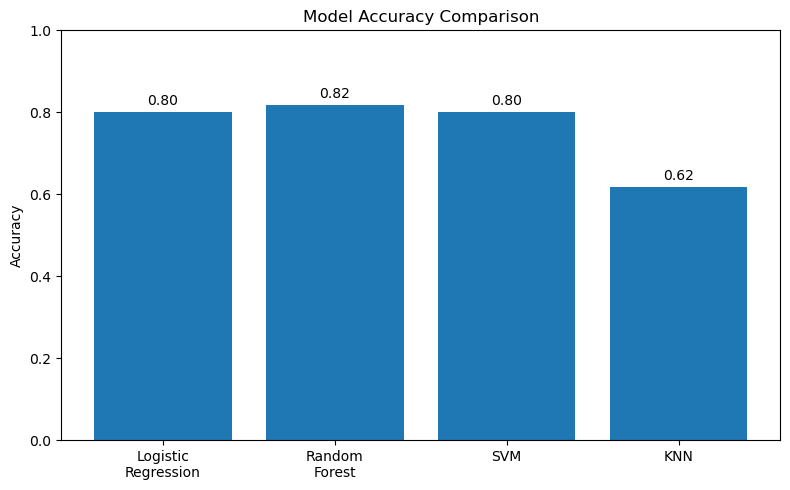

In [38]:
models = ["Logistic\nRegression", "Random\nForest", "SVM", "KNN"]

accs = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_knn)
]
plt.figure(figsize=(8,5))
bars = plt.bar(models, accs)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# add values on top
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.01,
             f"{h:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


## Model Accuracy Comparison – Interpretation
The model comparison shows that Random Forest achieved the highest accuracy, performing slightly better than Logistic Regression and SVM, which both achieved similar accuracy levels. This suggests that Random Forest may better capture complex relationships within the dataset. In contrast, KNN shows noticeably lower accuracy, indicating weaker predictive performance. Overall, Random Forest appears to be the most effective model for predicting heart disease in this analysis.

# 4.9 Confusion Matrix Analysis

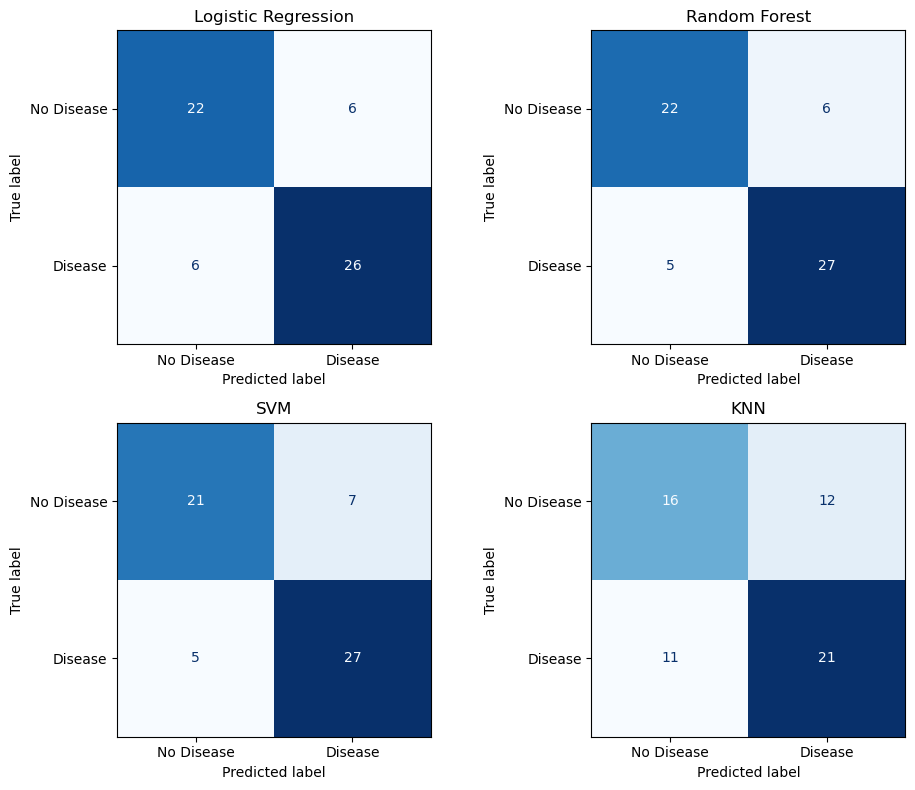

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds = {
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


## Confusion Matrix – Interpretation
The confusion matrices illustrate how well each model classifies patients with and without heart disease.
Logistic Regression correctly identifies most cases in both classes, with a balanced number of true positives and true negatives and relatively few misclassifications.
Random Forest shows slightly improved performance, correctly identifying more disease cases while maintaining similar accuracy for non-disease cases, resulting in fewer overall errors.
SVM performs similarly to logistic regression but shows slightly more misclassification of non-disease cases.
KNN shows the highest number of misclassifications in both categories, indicating weaker classification ability compared to the other models.
Overall, Random Forest provides the most accurate classification, while KNN demonstrates the weakest performance, supporting the earlier accuracy comparison results.

In [48]:
from sklearn.metrics import roc_auc_score

print("RF AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))
print("LR AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]))
print("SVM AUC:", roc_auc_score(y_test, svm_model.predict_proba(X_test)[:,1]))
print("KNN AUC:", roc_auc_score(y_test, knn_model.predict_proba(X_test)[:,1]))

RF AUC: 0.8694196428571428
LR AUC: 0.7232142857142856
SVM AUC: 0.5
KNN AUC: 0.6713169642857143


C:\Users\drhud\Downloads\pain\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\drhud\Downloads\pain\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


## Interpretation 
The ROC–AUC results indicate differences in the models’ ability to distinguish between heart disease and non-disease cases. Random Forest achieved the highest AUC, demonstrating the strongest discriminative capability among the models. Logistic Regression also shows good performance with a moderate AUC value. KNN achieves a moderate AUC, indicating some ability to differentiate between classes, though weaker than the top-performing models. In contrast, SVM shows an AUC close to 0.5, suggesting poor discriminative ability and performance similar to random classification. Overall, the results confirm that Random Forest provides the most reliable classification performance in this analysis.

# 5. Feature Importance Analysis
## 5.1 Random Forest Feature Importance
Random Forest feature importance was calculated to understand which predictors contribute most to the model’s decision-making process. In tree-based models, feature importance is determined by measuring how much each variable reduces impurity when used to split the data across the trees. Features that contribute more to improving classification are assigned higher importance values.

In [42]:
# Random Forest Feature Importance
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance.head(10)

max_heartrate_achieved     0.141731
major_vessels_number       0.131960
thallium_heart_scan        0.126187
st_depression              0.108241
chest_pain                 0.092616
age                        0.085618
cholesterol                0.078054
resting_blood_pressure     0.069297
exercise_induced_angina    0.057061
st_segment_slope           0.045544
dtype: float64

### Interpretation
The results show that maximum heart rate achieved, major vessels number, thallium heart scan, and ST depression are the most influential variables in the model. These features represent functional stress response and structural cardiac abnormalities, indicating that direct cardiac diagnostic indicators play a key role in predicting heart disease. Other variables such as chest pain and age also contribute moderately, while factors like resting blood pressure and fasting blood sugar show relatively lower importance.

## 5.2 Permutation Feature Importance
Permutation feature importance was performed to provide a more robust evaluation of feature influence by measuring how much model performance decreases when the values of a feature are randomly shuffled. If shuffling a feature causes a noticeable drop in model performance, it indicates that the model relies heavily on that feature for accurate predictions.

In [49]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc"
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

perm_importance.head(14)

major_vessels_number       0.060463
thallium_heart_scan        0.042662
chest_pain                 0.037723
st_depression              0.023465
sex                        0.022545
age                        0.017494
exercise_induced_angina    0.012137
st_segment_slope           0.010686
resting_ecg                0.004799
fasting_blood_sugar        0.000977
cholesterol               -0.001451
resting_blood_pressure    -0.002093
max_heartrate_achieved    -0.003683
dtype: float64

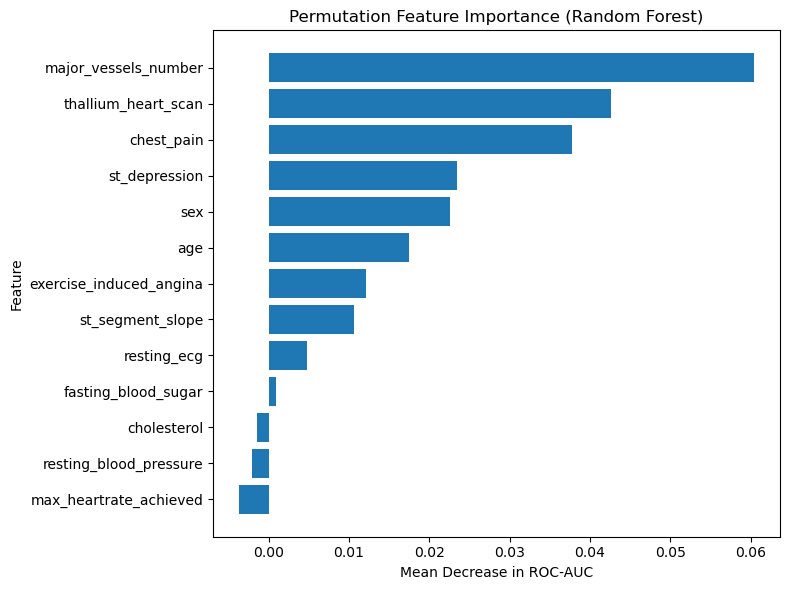

In [44]:
import matplotlib.pyplot as plt

# Sort in ascending order for horizontal bar plot
perm_importance_sorted = perm_importance.sort_values(ascending=True)

plt.figure(figsize=(8,6))
plt.barh(
    perm_importance_sorted.index,
    perm_importance_sorted.values
)

plt.title("Permutation Feature Importance (Random Forest)")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The permutation results highlight major vessels number, thallium heart scan, chest pain, and ST depression as the most important predictors. These findings are consistent with the Random Forest importance results, reinforcing that structural coronary indicators and stress-related cardiac measures strongly influence heart disease prediction. Features such as sex and age show moderate contributions, while variables like resting ECG and fasting blood sugar have minimal impact.

# Final Project Conclusion
This study developed and evaluated machine learning models to predict heart disease using clinical and diagnostic patient data. Exploratory analysis revealed that diagnostic and stress-related cardiac variables showed stronger associations with heart disease compared to general cardiovascular risk factors.

Among the numerical features, maximum heart rate achieved, ST depression, and number of major vessels demonstrated clearer differences between disease and non-disease groups. Similarly, categorical analysis indicated that thallium heart scan results, chest pain type, exercise-induced angina, and ST segment slope were strongly associated with heart disease.

Multiple machine learning models were trained and evaluated, including Logistic Regression, Random Forest, Support Vector Machine, and K-Nearest Neighbors. Model comparison showed that Random Forest achieved the highest predictive performance, followed closely by Logistic Regression and SVM, while KNN showed comparatively weaker results. ROC–AUC analysis further confirmed the superior discriminative ability of the Random Forest model.

Feature importance analysis using both Random Forest and permutation methods consistently identified major vessels number, thallium heart scan results, chest pain, ST depression, and maximum heart rate achieved as the most influential predictors. These findings suggest that direct cardiac diagnostic indicators and functional stress responses are more informative for heart disease prediction than general metabolic risk factors.

Overall, the results demonstrate that machine learning models, particularly Random Forest effectively identify key clinical patterns associated with heart disease and provide meaningful predictive insights from patient data.